In [1]:
import os
import sys
import logging
import time
import math
from pathlib import Path
import subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.sharding import NamedSharding, PartitionSpec, AxisType
from jax.experimental.sparse.linalg import lobpcg_standard
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from skqd_z2lgt.ground_locg import ground_locg
from skqd_z2lgt.sqd import get_hamiltonian_arrays, sqd
from skqd_z2lgt.ising_dmrg import ising_dmrg
from skqd_z2lgt.parameters import Parameters, DMRGParameters, LGTParameters
from skqd_z2lgt.tasks.open_output import open_output
from skqd_z2lgt.tasks.sample_quantum import sample_quantum
from skqd_z2lgt.tasks.preprocess import preprocess
from skqd_z2lgt.tasks.train_generator import train_generator
from skqd_z2lgt.tasks.diagonalize import diagonalize
sys.path.append('/home/iiyama/src/skqd_z2lgt/lib')
from ising_hamiltonian import make_apply_h, make_apply_u

visible_devices = '0,1,2,3'
# visible_devices = '9'
os.environ['CUDA_VISIBLE_DEVICES'] = visible_devices
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.99'
jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO)

python = '/home/iiyama/src/qii-miyabi-kawasaki/.venv/bin/python'
data_dir = Path('/data/iiyama/2dz2/buildup')

## Define a 4x7 lattice

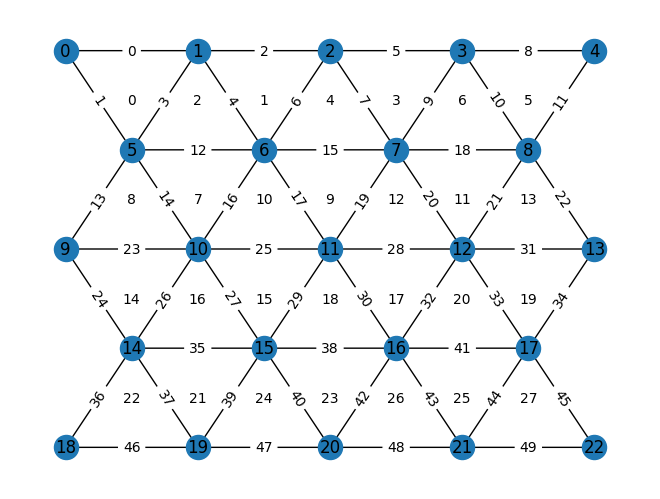

In [2]:
nrow, ncol = 4, 7
num_qubits = nrow * ncol
lattice = TriangularZ2Lattice((nrow, ncol))
lattice.draw_graph();

In [3]:
nsites = (ncol - 1) // 2 + 1 + (nrow // 2 + 1) % 2
vfirst = (lattice.num_vertices - nsites) // 2
links = []
for ivtx in range(vfirst, vfirst + nsites - 1):
    links.append(lattice.graph.edge_indices_from_endpoints(ivtx, ivtx + 1)[0])
print(links)
base_link_state = np.zeros(lattice.num_links, dtype=np.uint8)
base_link_state[::-1][links] = 1
dual_lattice = lattice.plaquette_dual(base_link_state)
hamiltonian = dual_lattice.make_hamiltonian(1.6)
apply_h = make_apply_h(hamiltonian)

[23, 25, 28, 31]


## Exact time evolution

In [4]:
filename = '/data/iiyama/2dz2/evolution_4x7_1.6.h5'

if not os.path.exists(filename):
    from jax.experimental.ode import odeint
    from jax.sharding import auto_axes

    def dpsidt(vec, _):
        return -1.j * apply_h(vec)

    mesh = jax.make_mesh((2, 2), ('X', 'Y'), (AxisType.Auto, AxisType.Auto))
    jax.set_mesh(mesh)
    sharding = NamedSharding(mesh, PartitionSpec(('X', 'Y')))

    @auto_axes(out_sharding=sharding)
    def integrate(vec, dt):
        if vec is None:
            vec = jax.device_put(jax.nn.one_hot(0, 2 ** hamiltonian.num_qubits, dtype=np.complex128), sharding)
        return odeint(dpsidt, vec, jnp.array([0., dt]))[1]
    
    with h5py.File(filename, 'w', libver='latest') as out:
        dataset = out.create_dataset('states', shape=(100, 2 ** hamiltonian.num_qubits), dtype=np.complex128)
        dataset[0, 0] = 1.
        state = None
        for iint in range(99):
            print(iint)
            state = integrate(state, 0.01)
            dataset[iint + 1] = state

In [5]:
idx1 = 1 << np.arange(28)
idx2 = np.arange(2 ** 28)
idx2 = idx2[np.bitwise_count(idx2) == 2]
with h5py.File(filename, 'r', libver='latest') as source:
    prob0 = np.square(np.abs(source['states'][:, 0]))
    prob1 = np.square(np.abs(source['states'][:, idx1]))
    prob2 = np.square(np.abs(source['states'][:, idx2]))

### Collective prob by excitation

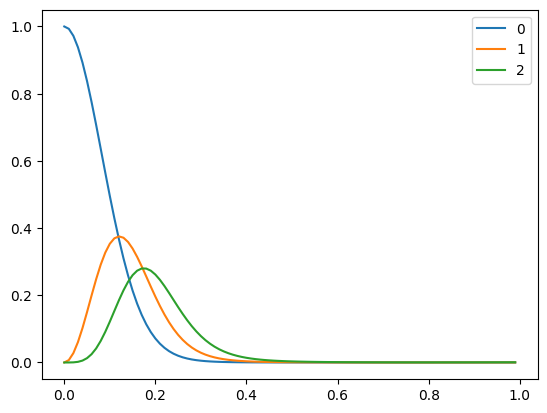

In [6]:
plt.plot(np.arange(100) / 100., prob0, label='0')
plt.plot(np.arange(100) / 100., np.sum(prob1, axis=1), label='1')
plt.plot(np.arange(100) / 100., np.sum(prob2, axis=1), label='2')
plt.legend();

### Individual within each excitation number

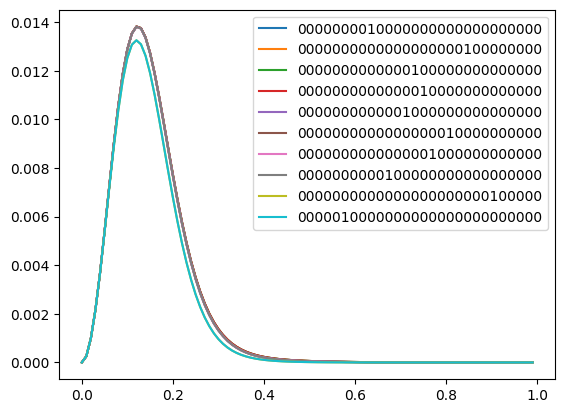

In [7]:
sorter = np.argsort(np.max(prob1, axis=0))[::-1]
plt.plot(np.arange(100) / 100., prob1[:, sorter[:10]], label=[f'{i:028b}' for i in idx1[sorter[:10]]])
plt.legend();

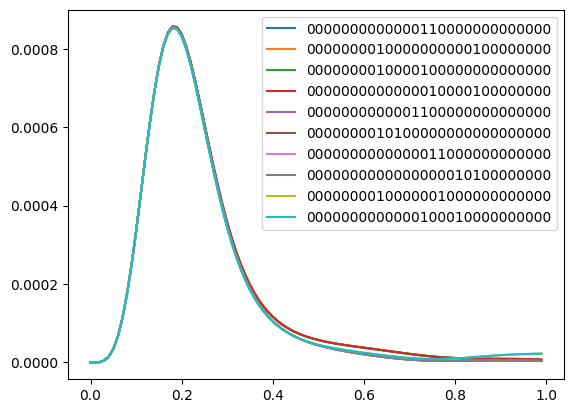

In [8]:
sorter = np.argsort(np.max(prob2, axis=0))[::-1]
plt.plot(np.arange(100) / 100., prob2[:, sorter[:10]], label=[f'{i:028b}' for i in idx2[sorter[:10]]])
plt.legend();

## Trotter evolution

In [9]:
filename = '/data/iiyama/2dz2/trotter_4x7_1.6.h5'
if os.path.exists(filename):
    with h5py.File(filename, 'r', libver='latest') as source:
        states = source['states'][()]
else:
    apply_u = make_apply_u(hamiltonian)
    states = np.zeros((5, 2 ** lattice.num_plaquettes), dtype=np.complex128)
    states[0, 0] = 1.
    for ip in range(4):
        states[ip + 1] = apply_u(states[ip], 0.25)

    with h5py.File(filename, 'w', libver='latest') as out:
        out.create_dataset('states', data=states)

In [10]:
tr_probs = np.square(np.abs(states))

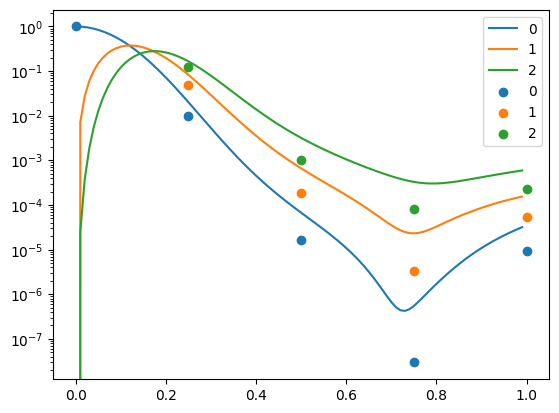

In [11]:
plt.plot(np.arange(100) / 100., prob0, label='0')
plt.plot(np.arange(100) / 100., np.sum(prob1, axis=1), label='1')
plt.plot(np.arange(100) / 100., np.sum(prob2, axis=1), label='2')
tpoints = np.linspace(0., 1., 5)
plt.scatter(tpoints, tr_probs[:, 0], label='0')
plt.scatter(tpoints, np.sum(tr_probs[:, idx1], axis=1), label='1')
plt.scatter(tpoints, np.sum(tr_probs[:, idx2], axis=1), label='2')
plt.yscale('log')
plt.legend();

## Exact ground state excitation distribution

In [12]:
filename = '/data/iiyama/2dz2/ground_4x7_1.6.h5'
if os.path.exists(filename):
    with h5py.File(filename, 'r', libver='latest') as source:
        eigval = source['eigval'][()]
        eigvec = source['eigvec'][()]
else:
    eigval, eigvec, iter = ground_locg(apply_h, 0, vspace=(2 ** lattice.num_plaquettes, np.float64))
    with h5py.File(filename, 'w', libver='latest') as out:
        out.create_dataset('eigval', data=eigval)
        out.create_dataset('eigvec', data=eigvec)

<BarContainer object of 29 artists>

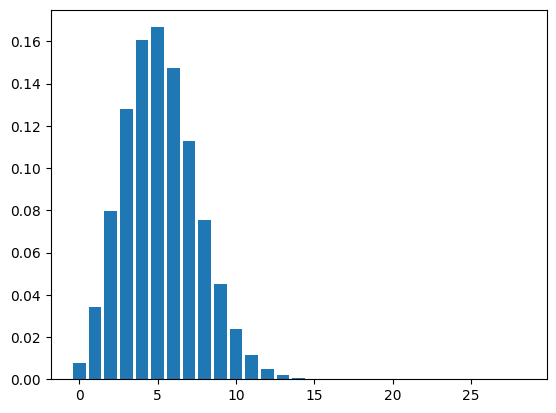

In [13]:
excitations = np.bitwise_count(np.arange(2 ** 28))
gprob = np.square(np.abs(eigvec))
histogram = np.zeros(29)
for iw in range(29):
    histogram[iw] = np.sum(gprob[excitations == iw])
plt.bar(np.arange(29), histogram)

### Probability distribution of 7-plaquette states

In [17]:
idx7 = np.nonzero(excitations == 7)[0]
g7 = gprob[idx7]
sorter = np.argsort(g7)[::-1]
idx7sorted = idx7[sorter]
g7sorted = g7[sorter]

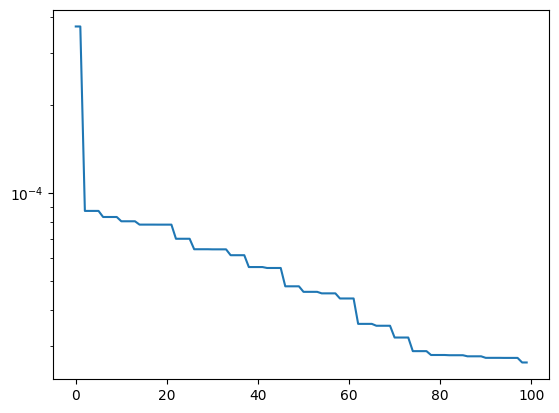

In [18]:
plt.plot(g7sorted[:100])
plt.yscale('log')

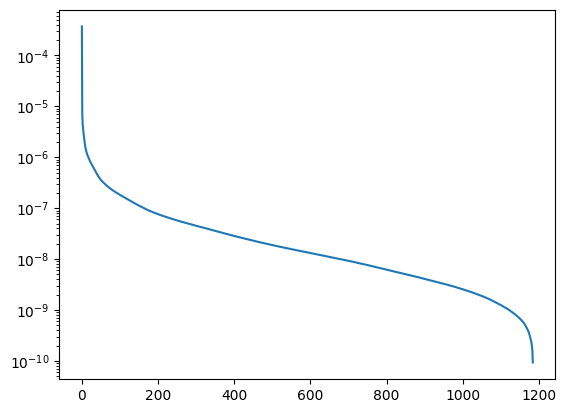

In [19]:
plt.plot(g7sorted[::1000])
plt.yscale('log')

In [20]:
for x, p in zip(idx7sorted[:20], g7sorted):
    print(f'{x:028b}', f'{p:.3e}')

0000000000000011111110000000 3.710e-04
0000000111111100000000000000 3.710e-04
0000100101111100000000000000 8.699e-05
0000000000000011111010010000 8.699e-05
0000100111111000000000000000 8.699e-05
0000000000000001111110010000 8.699e-05
0000100011111100000000000000 8.293e-05
0000000000000011011110010000 8.293e-05
0000100111101100000000000000 8.293e-05
0000000000000011111100010000 8.293e-05
0000001101111100000000000000 8.018e-05
0000000000000001111110000100 8.018e-05
0000000000000011111011000000 8.018e-05
0010000111111000000000000000 8.018e-05
0000000010000001111110000000 7.811e-05
0000000000000111111010000000 7.811e-05
0000000101111110000000000000 7.811e-05
0000000111111000000100000000 7.811e-05
0000001011111100000000000000 7.809e-05
0000000000000011011110000100 7.809e-05


## Do Trotter states capture the high-weight 7-plaquette states?

In [21]:
np.sum(tr_probs[:, idx7], axis=1)

array([0.        , 0.06907302, 0.0723221 , 0.02272896, 0.02411317])

At step 2, 7% of Trotter probability is on 7-plaquette. The ordering is:

In [22]:
sorter = np.argsort(tr_probs[2, idx7])[::-1]
tr_idx7sorted = idx7[sorter]
tr_probssorted = tr_probs[2, tr_idx7sorted]

In [23]:
for x, p in zip(tr_idx7sorted[:100], tr_probssorted):
    print(f'{x:028b}', f'{p:.3e}')

0000000111111100000000000000 3.118e-06
0000000000000011111110000000 3.118e-06
0000000110111110000000000000 2.340e-06
0000000110111100000100000000 2.340e-06
0000000010000011110110000000 2.340e-06
0000000000000111110110000000 2.340e-06
0000000000011111100100000000 2.227e-06
0000000110100100010110000000 2.227e-06
0000000110100010010110000000 2.227e-06
0000000010011111100000000000 2.227e-06
0000000110100001011100000000 2.193e-06
0000000011101000010110000000 2.193e-06
0000000001101111100000000000 2.193e-06
0000000000011111011000000000 2.193e-06
0000001110111100000000000000 2.131e-06
0010000110111100000000000000 2.131e-06
0000000000000011110111000000 2.131e-06
0000000000000011110110000100 2.131e-06
0000000110100101011000000000 2.130e-06
0000000001101010010110000000 2.130e-06
0000000001101011100100000000 2.130e-06
0000000010011101011000000000 2.130e-06
0000000111100000010110000000 2.099e-06
0000000110100000011110000000 2.099e-06
0000000001011111100000000000 2.099e-06
0000000000011111101000000

## SQD with <= 6 plaquettes PT states

In [24]:
filename = '/data/iiyama/2dz2/buildup/pt_states_28plaq.h5'
with h5py.File(filename, 'r', libver='latest') as source:
    pt_states = np.concatenate([source[f'states_{i}'][()] for i in range(7)], axis=0)

In [25]:
sqd_eigval, sqd_vec = sqd(hamiltonian, pt_states)

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:skqd_z2lgt.sqd:Sorted 499178 bitstrings in 5.228690 seconds. Subspace dimension 499178
INFO:skqd_z2lgt.sqd:Found ground eigenpair in 16.658042 seconds.


In [26]:
print(eigval, sqd_eigval)

-58.81344432994643 -57.53365606294084


## SQD with quantum samples with >=7 plaquettes

In [35]:
rng = np.random.default_rng()
samples = rng.choice(2 ** 28, size=10_000_000, p=tr_probs[2])

In [36]:
samples_ge7 = np.unique(samples[np.bitwise_count(samples) >= 7])
skqd_states = np.concatenate([pt_states, ((samples_ge7[:, None] >> np.arange(28)[None, ::-1]) % 2).astype(np.uint8)], axis=0)
skqd_eigval, skqd_vec = sqd(hamiltonian, skqd_states)

INFO:skqd_z2lgt.sqd:Sorted 8213194 bitstrings in 7.049748 seconds. Subspace dimension 8213194
INFO:skqd_z2lgt.sqd:Found ground eigenpair in 22.678562 seconds.


In [37]:
skqd_eigval

-57.97430602933915

### Reference: random augmentation

In [38]:
samples_rnd = rng.choice(2 ** 28, size=10_000_000)
samples_rnd_ge7 = np.unique(samples_rnd[np.bitwise_count(samples_rnd) >= 7])
rnd_states = np.concatenate([pt_states, ((samples_rnd_ge7[:, None] >> np.arange(28)[None, ::-1]) % 2).astype(np.uint8)], axis=0)
rnd_eigval, skqd_vec = sqd(hamiltonian, rnd_states)

INFO:skqd_z2lgt.sqd:Sorted 10297478 bitstrings in 7.345046 seconds. Subspace dimension 10297478
INFO:skqd_z2lgt.sqd:Found ground eigenpair in 23.462015 seconds.


In [39]:
rnd_eigval

-57.54453850937934